# 딥러닝 기초 II — 텐서플로우와 딥러닝 학습 방법
## Google Colab 실습용 노트북

이 노트북은 강의 자료 **2장 텐서플로우와 딥러닝 학습 방법**을 Colab에서 바로 실행할 수 있도록 구성했습니다.

**학습 목표**
- 손실 함수, 경사하강법, 순전파/역전파의 학습 원리를 수식으로 이해한다.
- TensorFlow 2.x의 Eager Execution과 텐서 기초 API를 익힌다.
- Keras로 딥러닝 모델을 구축·학습·평가·예측하는 4단계를 실습한다.
- Epoch / Batch / Iteration 관계를 코드로 확인한다.

**목차**
1. 딥러닝 모델의 학습 방법
2. 텐서플로우(TensorFlow)
3. 텐서플로우 기초 사용법
4. 텐서플로우로 딥러닝 모델 구현하기

> Colab 사용 팁: 런타임 → 런타임 유형 변경 → **GPU**를 선택하면 학습이 더 빠릅니다. (이 노트북의 예제는 CPU로도 충분합니다.)


---
## 0. Colab 환경 설정

TensorFlow 2.x는 Colab에 기본 설치되어 있습니다. 버전과 Eager Execution 여부를 먼저 확인합니다.


In [1]:
import sys
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

In [2]:
# =====================================================================
# 1. 시스템 경고 및 기본 데이터 분석 라이브러리 설정
# =====================================================================
import warnings
# 향후 버전 업데이트 안내 등 분석에 방해되는 불필요한 경고 메시지를 숨깁니다.
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})


# =====================================================================
# 2. 딥러닝 프레임워크 (TensorFlow & Keras) 불러오기
# =====================================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =====================================================================
# 3. 난수 고정 (결과의 재현성 보장)
# =====================================================================
# 딥러닝 모델은 가중치 초기화나 데이터 셔플링 시 난수(무작위수)를 사용합니다.
# 동일한 난수 시드(Seed)를 지정하면 언제 실행해도 항상 같은 실험 결과를 얻을 수 있습니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)      # NumPy 수학 연산용 난수 고정
tf.random.set_seed(RANDOM_STATE)  # TensorFlow 딥러닝 연산용 난수 고정

# =====================================================================
# 4. 현재 실행 환경 검증 및 출력
# =====================================================================
print('TensorFlow version:', tf.__version__)

# Eager Execution(즉시 실행 모드): 그래프 빌드 없이 코드를 즉시 실행하는 모드 (TF 2.x 기본 활성화)
print('Eager Execution 활성화:', tf.executing_eagerly())

# 모델 가속을 위한 GPU 장치가 올바르게 할당되었는지 확인합니다.
# 리스트가 비어있다면 CPU 모드, 장치가 들어있다면 GPU 학습이 가능한 상태입니다.
print('사용 가능한 GPU:', tf.config.list_physical_devices('GPU'))
print('환경 설정 완료')

TensorFlow version: 2.20.0
Eager Execution 활성화: True
사용 가능한 GPU: []
환경 설정 완료


---
# 01. 딥러닝 모델의 학습 방법

## 1) 딥러닝 모델의 정의와 구성 요소

- **딥러닝 (Deep Learning)**: 입력층과 출력층 사이에 **은닉층(Hidden Layer)이 깊게(강의 기준 3층 이상)** 쌓인 신경망
- **레이어 (Layer)**: 모델을 구성하는 층
- **노드 / 유닛 (Node / Unit)**: 각 층을 구성하는 계산 단위
- **가중치 (Weight)**: 노드 간 연결 강도

한 층의 선형 변환은 다음과 같이 씁니다.

$$
z = W x + b
$$

활성화 함수를 거치면

$$
a = f(z)
$$

입니다. 예: Sigmoid

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$


## 2) 손실 함수(Loss Function)와 최적화(Optimization)

- **손실 함수**: 정답 $y$와 예측 $\hat{y}$의 오차
- **최적화**: 손실을 줄이도록 가중치 $W$, 편향 $b$를 찾는 과정

회귀에서 자주 쓰는 MSE:

$$
\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

이진 분류에서 자주 쓰는 BCE:

$$
\mathrm{BCE} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]
$$


## 3) 경사하강법 (Gradient Descent)

손실 함수를 최소화하기 위해, 현재 가중치에서의 **기울기(Gradient)** 반대 방향으로 갱신합니다.

$$
W_{t+1} = W_t - \alpha \nabla_W \mathrm{Loss}(W_t)
$$

$$
b_{t+1} = b_t - \alpha \nabla_b \mathrm{Loss}(b_t)
$$

- $W_t$: 현재 가중치
- $\alpha$: **학습률 (learning rate)**
- $\nabla_W \mathrm{Loss}$: 손실의 $W$에 대한 기울기

1차원 이차 함수 예시:

$$
L(w) = (w - 3)^2
$$

이면

$$
\frac{dL}{dw} = 2(w-3)
$$

이므로

$$
w_{t+1} = w_t - \alpha \cdot 2(w_t - 3)
$$

로 갱신됩니다.


=== 경사하강법 수렴 직전 기록 (마지막 5단계) ===
    step         w      loss      grad
25    25  2.988666  0.000128 -0.022667
26    26  2.990933  0.000082 -0.018134
27    27  2.992746  0.000053 -0.014507
28    28  2.994197  0.000034 -0.011606
29    29  2.995358  0.000022 -0.009285


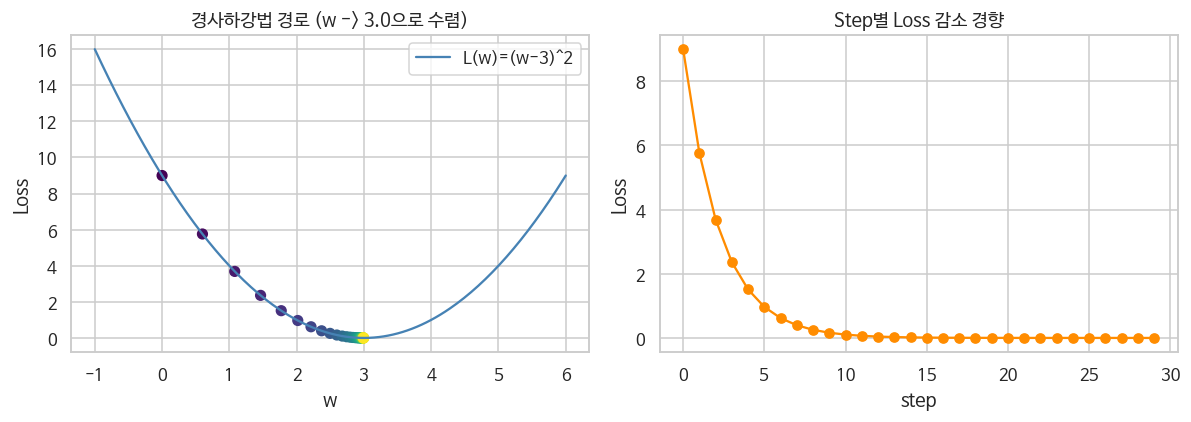

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. 손실 함수(Loss Function) 및 경사(Gradient) 정의
# =====================================================================

def loss_fn(w):
    """
    1차원 가중치 w에 대한 손실 함수 L(w) = (w - 3)^2 을 계산합니다.
    - 최적의 가중치는 L(w)가 최소가 되는 w = 3.0 (최솟값 0) 입니다.
    """
    return (w - 3.0) ** 2


def grad_fn(w):
    """
    손실 함수 L(w)를 w에 대해 미분한 도함수(Gradient)를 계산합니다.
    - L'(w) = 2 * (w - 3.0)
    - 미분값은 현재 위치에서 함수가 '가장 가파르게 증가하는 방향'을 가리킵니다.
    """
    return 2.0 * (w - 3.0)


# =====================================================================
# 2. 경사하강법(Gradient Descent) 하이퍼파라미터 및 초기값 설정
# =====================================================================
alpha = 0.1     # 학습률 (Learning Rate): 가중치를 한 번에 얼마나 크게 업데이트할지 결정하는 보폭
w = 0.0         # 초기 가중치 설정: 원점(0.0)에서 탐색을 시작합니다.
history = []    # 각 반복 단계(Step)별 정보를 기록할 리스트


# =====================================================================
# 3. 경사하강법 루프 실행 (30 Step)
# =====================================================================
for t in range(30):
    # 1) 현재 가중치 w에서의 미분값(기울기)을 계산합니다.
    g = grad_fn(w)

    # 2) 시각화 및 데이터 분석을 위해 현재 상태(단계, 가중치, 손실값, 기울기)를 기록합니다.
    history.append({
        'step': t,
        'w': w,
        'loss': loss_fn(w),
        'grad': g
    })

    # 3) 가중치 업데이트 공식 적용: W_{t+1} = W_t - alpha * L'(W_t)
    #    - 기울기의 반대 방향(-)으로 보폭(alpha)만큼 이동합니다.
    w = w - alpha * g


# 4. 기록된 히스토리 리스트를 Pandas DataFrame으로 변환하여 마지막 5단계 확인
hist_df = pd.DataFrame(history)
print("=== 경사하강법 수렴 직전 기록 (마지막 5단계) ===")
print(hist_df.tail())


# =====================================================================
# 4. 경사하강법 학습 경로 및 손실 감소 시각화
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# [왼쪽 그래프]: 손실 곡선 상의 경사하강법 경로 시각화
# - -1부터 6까지 200개의 구간을 촘촘히 나누어 2차 곡선 배경을 그립니다.
ws = np.linspace(-1, 6, 200)
axes[0].plot(ws, loss_fn(ws), color='steelblue', label='L(w)=(w-3)^2')

# - 가중치 w가 업데이트되는 경로를 점으로 찍어 표현합니다.
# - c=hist_df['step'], cmap='viridis': 학습 초기(어두운 보라색)부터 후기(밝은 노란색)까지 시간 흐름을 색상으로 보여줍니다.
axes[0].scatter(hist_df['w'], hist_df['loss'], c=hist_df['step'], cmap='viridis', s=40)
axes[0].set_title('경사하강법 경로 (w -> 3.0으로 수렴)')
axes[0].set_xlabel('w')
axes[0].set_ylabel('Loss')
axes[0].legend()


# [오른쪽 그래프]: 단계(Step)에 따른 손실값(Loss)의 변화 추이
# - 에포크가 진행됨에 따라 손실이 지수 함수적으로 0에 수렴해가는 과정을 보여줍니다.
axes[1].plot(hist_df['step'], hist_df['loss'], marker='o', color='darkorange')
axes[1].set_title('Step별 Loss 감소 경향')
axes[1].set_xlabel('step')
axes[1].set_ylabel('Loss')

# 여백 조절 후 최종 화면 출력
plt.tight_layout()
plt.show()

## 4) 순전파와 역전파

### 순전파 (Forward Propagation)

입력이 입력층 → 은닉층 → 출력층으로 흘러 예측값을 만듭니다.

$$
\begin{aligned}
z^{(1)} &= W^{(1)}x + b^{(1)} \\
a^{(1)} &= f(z^{(1)}) \\
z^{(2)} &= W^{(2)}a^{(1)} + b^{(2)} \\
\hat{y} &= f(z^{(2)})
\end{aligned}
$$

### 역전파 (Backpropagation)

출력층에서 입력층 방향으로 오차를 전파하며 각 가중치의 기울기를 계산합니다.  
연쇄법칙(Chain Rule):

$$
\frac{\partial L}{\partial W^{(1)}}
=
\frac{\partial L}{\partial \hat{y}}
\cdot
\frac{\partial \hat{y}}{\partial z^{(2)}}
\cdot
\frac{\partial z^{(2)}}{\partial a^{(1)}}
\cdot
\frac{\partial a^{(1)}}{\partial z^{(1)}}
\cdot
\frac{\partial z^{(1)}}{\partial W^{(1)}}
$$

즉, 어떤 가중치의 기울기를 구하려면 **그 앞단(출력 쪽)의 미분값**이 필요합니다.

### 관련 논문 / 자료

- Rumelhart, Hinton, Williams (1986): [Learning representations by back-propagating errors](https://www.nature.com/articles/323533a0)
- Goodfellow et al., *Deep Learning* Book: [https://www.deeplearningbook.org/](https://www.deeplearningbook.org/)


In [4]:
import tensorflow as tf

# =====================================================================
# 1. 고정 데이터(상수) 및 학습 대상(변수) 선언
# =====================================================================

# tf.constant: 값이 변하지 않는 고정된 상수 텐서를 정의합니다. (입력 데이터 및 정답 라벨)
x = tf.constant(2.0)       # 입력값 (Feature)
y_true = tf.constant(1.0)  # 실제 정답 (Target / Label)

# tf.Variable: 모델 학습 과정에서 경사하강법을 통해 업데이트될 '가중치와 편향'을 정의합니다.
# - tf.GradientTape는 기본적으로 모든 tf.Variable에 대한 연산을 자동으로 기록하고 추적합니다.
w = tf.Variable(0.5)       # 가중치 (Weight) 초기값: 0.5
b = tf.Variable(-1.0)      # 편향 (Bias) 초기값: -1.0


# =====================================================================
# 2. GradientTape를 활용한 순전파(Forward Pass) 연산 기록
# =====================================================================

# with tf.GradientTape() 블록 내부에서 일어나는 모든 텐서 연산은 '테이프(Tape)'에 기록됩니다.
# - 기록된 연산 그래프를 역방향으로 추적하여 나중에 미분값(Gradient)을 계산합니다.
with tf.GradientTape() as tape:
    # 1) 선형 결합 (z = w * x + b) 계산
    #    - z = 0.5 * 2.0 + (-1.0) = 0.0
    z = w * x + b

    # 2) 활성화 함수 (Sigmoid) 적용
    #    - y_hat = 1 / (1 + e^(-z)) = 1 / (1 + e^0) = 0.5
    y_hat = tf.math.sigmoid(z)

    # 3) 손실 계산 (Loss: 오차 제곱합, Mean Squared Error)
    #    - loss = (1.0 - 0.5)^2 = 0.25
    loss = (y_true - y_hat) ** 2


# =====================================================================
# 3. 역전파(Backpropagation) - 자동 미분(Auto-Grad) 수행
# =====================================================================

# tape.gradient(target, sources) 메서드를 호출하여 미분값(기울기)을 도출합니다.
# - target: 미분하고자 하는 최종 결과값 (보통 손실함수인 loss)
# - sources: 어떤 변수로 미분할 것인지 지정 (학습 대상인 가중치 w와 편향 b)
# - 수식적 의미: [dL/dw, dL/db] 편미분값 계산
grads = tape.gradient(loss, [w, b])


# =====================================================================
# 4. 연산 결과 및 미분값(Gradient) 출력
# =====================================================================

# tf.Tensor 객체에서 실제 실수값만 추출하기 위해 float() 형변환을 적용해 출력합니다.
print('y_hat =', float(y_hat))   # 모델이 예측한 확률값 (0.5)
print('loss  =', float(loss))    # 정답과의 오차 제곱값 (0.25)

# dL/dw (가중치 w에 대한 손실함수 L의 기울기)
# - 이 값이 음수이므로, w를 양의 방향으로 증가시켜야 손실(Loss)이 감소합니다.
print('dL/dw =', float(grads[0]))

# dL/db (편향 b에 대한 손실함수 L의 기울기)
print('dL/db =', float(grads[1]))

y_hat = 0.5
loss  = 0.25
dL/dw = -0.5
dL/db = -0.25


---
# 02. 텐서플로우(TensorFlow)

## 1) 프레임워크가 필요한 이유

딥러닝을 밑바닥부터 구현하려면
- 행렬/미분 연산
- GPU 제어
- 대규모 데이터 파이프라인

까지 직접 다뤄야 합니다.  
**프레임워크**는 이를 추상화해 모델 구현·학습·추론을 쉽게 만듭니다.

한 번의 forward 연산을 추상화하면 다음과 같습니다.

$$
y = f_\theta(x) = f_L \circ f_{L-1} \circ \cdots \circ f_1(x)
$$

여기서 $\theta$는 모든 레이어의 가중치·편향 집합입니다.

## 2) TensorFlow의 의미

- **Tensor**: 다차원 배열 데이터
- **Flow**: 데이터가 연산 그래프의 노드를 따라 흐르며 계산되는 과정

랭크 $r$인 텐서의 shape를 $(n_1, n_2, \ldots, n_r)$라 하면, 원소 개수는

$$
|T| = \prod_{i=1}^{r} n_i
$$

입니다.

| Rank | 이름 | 예시 shape |
|------|------|------------|
| 0 | Scalar | `()` |
| 1 | Vector | `(3,)` |
| 2 | Matrix | `(2, 3)` |
| 3 | 3D Tensor | `(2, 3, 4)` |

데이터 플로우 그래프에서 각 노드는 연산, 에지는 텐서 흐름입니다.

$$
x \xrightarrow{\;op_1\;} t_1 \xrightarrow{\;op_2\;} t_2 \xrightarrow{\;op_3\;} y
$$

## 3) TF 1.x vs 2.x

- **1.x**: Graph 정의 → Session 실행이 필요
- **2.x (2019.09~)**: **Eager Execution**이 기본. 파이썬처럼 바로 결과 확인 가능

Eager에서는 연산이 정의와 동시에 평가됩니다.

$$
\texttt{result} = \texttt{tf.add}(a, b) \quad \Rightarrow \quad \text{즉시 } a+b \text{ 계산}
$$

공식 문서: [TensorFlow](https://www.tensorflow.org/), [Eager Execution](https://www.tensorflow.org/guide/eager)


In [5]:
import tensorflow as tf

# =====================================================================
# 1. 2D 텐서(행렬) 생성 및 선언
# =====================================================================

# tf.constant를 사용하여 (2, 2) 크기의 2차원 실수형(float32) 텐서를 생성합니다.
# - 별도의 데이터 타입을 지정하지 않으면 소수점 값을 보고 자동으로 float32로 할당합니다.
a = tf.constant([[1.0, 2.0],
                 [3.0, 4.0]])

b = tf.constant([[5.0, 6.0],
                 [7.0, 8.0]])


# =====================================================================
# 2. 즉시 실행(Eager Execution) 기반의 연산 수행
# =====================================================================

# 1) 요소별 덧셈 (Element-wise Addition)
#    - 두 행렬의 같은 위치에 있는 원소끼리 더합니다. (1+5, 2+6, 3+7, 4+8)
c = a + b

# 2) 행렬 곱셈 (Matrix Multiplication)
#    - tf.matmul 연산을 수행하며, 수학적인 행렬 곱(Dot Product) 연산입니다.
#    - d[0,0] = 1*5 + 2*7 = 19
#    - d[0,1] = 1*6 + 2*8 = 22
#    - d[1,0] = 3*5 + 4*7 = 43
#    - d[1,1] = 3*6 + 4*8 = 50
#    - Python 표준 연산자인 `@` 기호를 사용하여 `a @ b` 로도 똑같이 연산할 수 있습니다.
d = tf.matmul(a, b)


# =====================================================================
# 3. .numpy() 메서드를 활용한 데이터 변환 및 속성 출력
# =====================================================================

# 1) c.numpy() : 텐서플로우 내부 텐서 객체를 파이썬 환경에서 다루기 쉬운 'NumPy 배열'로 즉시 변환합니다.
#    - 즉시 실행 모드가 켜져 있기 때문에, 세션(Session) 구동 없이 즉시 데이터 확인이 가능합니다.
print('a + b =\n', c.numpy())
print('a @ b =\n', d.numpy())

# 2) tf.rank(a) : 텐서의 '축(Axis)의 개수' 즉, 차원(Dimension)의 수를 반환합니다.
#    - 2차원 행렬(Matrix)이므로 Rank는 2가 나옵니다.
#    - 이 역시 .numpy()를 사용해 정수값으로 보기 편하게 추출합니다.
# 3) a.shape : 텐서의 형태(크기)를 가진 튜플 속성을 반환합니다. -> TensorShape([2, 2])
print('rank(a) =', tf.rank(a).numpy(), ', shape =', a.shape)

a + b =
 [[ 6.  8.]
 [10. 12.]]
a @ b =
 [[19. 22.]
 [43. 50.]]
rank(a) = 2 , shape = (2, 2)


---
# 03. 텐서플로우 기초 사용법

## 1) 텐서의 종류

1. **Constant Tensor**: 값이 고정
2. **Sequence Tensor**: 규칙적 증가/간격 데이터
3. **Variable Tensor**: 학습 중 업데이트되는 파라미터

## 2) 주요 API

상수:

$$
A = \mathrm{constant}(value),\quad
O = \mathrm{zeros}(shape),\quad
I = \mathrm{ones}(shape)
$$

시퀀스:

$$
\mathrm{linspace}(start, stop, num),\quad
\mathrm{range}(start, limit, delta)
$$

변수:

$$
W \leftarrow \mathrm{Variable}(W_0)
$$


In [6]:
import tensorflow as tf

# =====================================================================
# 1) 상수 텐서 (Constant Tensor)
#    - 생성된 이후에는 값이 변하지 않는 고정된 형태의 텐서입니다.
# =====================================================================

# tf.constant: 주어진 파이썬 리스트를 지정한 데이터 타입(float32)의 텐서로 변환합니다.
tensor_a = tf.constant([1, 2, 3], dtype=tf.float32)

# tf.zeros: 모든 원소의 값이 0인 지정된 크기(Shape)의 텐서를 생성합니다.
# - shape=(2, 3): 2행 3열 크기
tensor_b = tf.zeros(shape=(2, 3), dtype=tf.float32)

# tf.ones: 모든 원소의 값이 1인 지정된 크기(Shape)의 텐서를 생성합니다.
tensor_c = tf.ones(shape=(2, 3), dtype=tf.float32)

# 출력 결과 확인 (.numpy()를 이용해 NumPy 배열로 변환)
print('constant:', tensor_a.numpy())
print('zeros:\n', tensor_b.numpy())
print('ones:\n', tensor_c.numpy())


# =====================================================================
# 2) 시퀀스 텐서 (Sequence Tensor)
#    - 일정한 규칙에 따라 순차적으로 증가하거나 감소하는 숫자의 배열을 만듭니다.
# =====================================================================

# tf.linspace(start, stop, num): start부터 stop까지 구간을 균등하게 num개로 분할합니다.
# - 0.0부터 1.0까지 균등하게 5개로 분할 -> [0.  , 0.25, 0.5 , 0.75, 1.  ]
tensor_d = tf.linspace(0.0, 1.0, 5)

# tf.range(start, limit, delta): start부터 limit 미만까지 delta 간격으로 숫자를 생성합니다.
# - 0부터 10 미만까지 2씩 증가 -> [0, 2, 4, 6, 8]
tensor_e = tf.range(start=0, limit=10, delta=2)

print('linspace:', tensor_d.numpy())
print('range   :', tensor_e.numpy())


# =====================================================================
# 3) 변수 텐서 (Variable Tensor)
#    - 가중치(Weights)나 편향(Bias)처럼, 모델 학습 과정에서 수시로 업데이트되는 값을 담습니다.
#    - 일반 대입 연산자(=) 대신 전용 메서드(.assign)를 사용해 값을 변경합니다.
# =====================================================================

# tf.Variable: 초기값(initial_value)과 선택적 속성(이름 등)을 정의하여 변수를 선언합니다.
tensor_f = tf.Variable(initial_value=[0.1, -0.2, 0.3], dtype=tf.float32, name='weights')
print('variable before:', tensor_f.numpy())

# .assign(): 변수 텐서에 새로운 값을 할당(덮어쓰기)합니다.
# - 가중치를 다른 값으로 수동 교체하거나 최적화 과정(Optimization)에서 텐서의 값을 갱신할 때 쓰입니다.
# - 이때 덮어쓰려는 데이터의 크기(Shape)와 데이터 타입(Dtype)이 처음 정의된 변수와 완전히 일치해야 합니다.
tensor_f.assign([1.0, 2.0, 3.0])
print('variable after :', tensor_f.numpy())

constant: [1. 2. 3.]
zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones:
 [[1. 1. 1.]
 [1. 1. 1.]]
linspace: [0.   0.25 0.5  0.75 1.  ]
range   : [0 2 4 6 8]
variable before: [ 0.1 -0.2  0.3]
variable after : [1. 2. 3.]


## 3) 선형 변환 수식 정의

강의 자료의 기본 연산:

$$
f(x) = W \cdot x + b
$$

아래에서는 벡터 내적/브로드캐스팅을 이용해 같은 식을 TensorFlow로 계산합니다.


In [7]:
import tensorflow as tf

# =====================================================================
# 1. 선형 변환을 위한 가중치(W), 편향(b), 입력값(x) 정의
# =====================================================================

# 가중치 W: 1행 2열 크기(Shape: (1, 2))의 변수 텐서
# - 입력 특징(Feature)이 2개이고 출력 뉴런이 1개일 때 가중치의 형태를 나타냅니다.
W = tf.Variable([[1.0, -1.0]], dtype=tf.float32)

# 편향 b: 1차원 크기(Shape: (1,))의 변수 텐서
# - 최종 행렬 곱 연산 결과에 더해집니다.
b = tf.Variable([0.5], dtype=tf.float32)

# 입력 x: 2행 1열 크기(Shape: (2, 1))의 고정된 상수 텐서 (열 벡터 형태)
x = tf.constant([[1.0], [0.0]], dtype=tf.float32)


# =====================================================================
# 2. 순전파(Forward Pass) 연산 정의 및 계산
# =====================================================================

def forward(x):
    """
    입력 x에 대해 선형 결합 f(x) = W * x + b 를 계산하는 함수입니다.

    [차원 연산 프로세스]
    - W의 크기: (1, 2)
    - x의 크기: (2, 1)
    - 행렬 곱(tf.matmul): (1, 2) @ (2, 1) -> (1, 1) 크기의 결과물 반환
      * 연산 결과: [[ (1.0 * 1.0) + (-1.0 * 0.0) ]] = [[1.0]]
    - 편향(b) 덧셈: [[1.0]] (1, 1) + [0.5] (1,)
      * 브로드캐스팅(Broadcasting)이 일어나 크기가 [[1.5]] (1, 1) 로 변환되어 정상 합산됩니다.
    """
    return tf.matmul(W, x) + b


# 3. 함수 실행을 통한 연산 결과 도출
output = forward(x)


# =====================================================================
# 3. 텐서들의 원래 형태 및 연산 결과 출력
# =====================================================================

print('W =', W.numpy())                            # 2차원 행렬 가중치 확인
print('x =', x.numpy().ravel())                    # 2차원 열 벡터 x를 1차원으로 평평하게(ravel) 펴서 출력
print('b =', b.numpy())                            # 편향 값 확인
print('f(x) = W·x + b =', float(output))           # (1, 1) 크기의 최종 텐서에서 실수(Float) 단일값만 추출하여 출력 (1.5)

W = [[ 1. -1.]]
x = [1. 0.]
b = [0.5]
f(x) = W·x + b = 1.5


---
# 04. 텐서플로우로 딥러닝 모델 구현하기

## 1) 구현 4단계

1. 데이터셋 준비하기  
2. 딥러닝 모델 구축하기  
3. 모델 학습시키기  
4. 평가 및 예측하기  

## 2) Epoch, Batch, Iteration

$$
1\ \mathrm{Epoch}
=
\frac{\text{총 데이터 개수}}{\text{Batch Size}}
=
\text{총 Iteration 횟수}
$$

예시: 데이터 1000개, Batch Size = 100 이면

$$
\text{Iteration per Epoch} = \frac{1000}{100} = 10
$$

즉, 1 Epoch를 끝내려면 10 Iteration이 필요합니다.


In [8]:
import numpy as np
import tensorflow as tf

# 랜덤 시드 고정 (재현성 확보)
RANDOM_STATE = 42

# ==========================================
# 1. Epoch / Batch / Iteration 개념 이해
# ==========================================

n_data = 1000      # 총 데이터 수 (Dataset의 전체 크기)
batch_size = 100   # 배치 사이즈 (모델이 한 번의 학습 단계에서 볼 데이터 개수)
epochs = 3         # 에포크 (전체 데이터를 총 몇 번 반복해서 학습할 것인가)

# 1 에포크당 이터레이션: 전체 데이터를 배치 사이즈로 나눈 몫 (가중치 업데이트 횟수)
iterations_per_epoch = n_data // batch_size

# 총 이터레이션: 전체 학습 과정 동안 일어나는 총 가중치 업데이트 횟수
total_iterations = iterations_per_epoch * epochs

# 계산 결과 출력
print(f'총 데이터 수        : {n_data}')
print(f'Batch Size         : {batch_size}')
print(f'1 Epoch당 Iteration: {iterations_per_epoch}')
print(f'{epochs} Epoch 총 Iteration: {total_iterations}')
print('-' * 40)


# ==========================================
# 2. tf.data.Dataset을 활용한 데이터 파이프라인 구축
# ==========================================

# 가상의 입력 데이터(X) 생성: 정규분포를 따르는 (1000, 2) 형태의 행렬
data = np.random.randn(n_data, 2).astype(np.float32)

# 가상의 레이블(y) 생성: 두 특성의 합이 0보다 크면 1, 아니면 0 (이진 분류용)
labels = (data[:, 0] + data[:, 1] > 0).astype(np.float32)

# 메모리의 텐서(Tensor) 데이터를 텐서플로 데이터셋 객체로 변환
dataset = tf.data.Dataset.from_tensor_slices((data, labels))

# 데이터 셔플(Shuffle) 및 배치(Batch)화
# - shuffle(): 에포크마다 데이터를 무작위로 섞어 모델의 과적합을 방지 (버퍼 크기는 데이터 총 수로 설정)
# - batch(): 데이터를 설정한 batch_size(100) 단위로 묶음
dataset = dataset.shuffle(n_data, seed=RANDOM_STATE).batch(batch_size)

# 생성된 총 배치 개수 확인 (iterations_per_epoch의 결과인 10과 일치해야 함)
print('생성된 총 배치 개수:', len(list(dataset)))

# 데이터셋에서 첫 번째 배치(1개)만 가져와서 데이터의 형태(Shape) 검증
for batch_x, batch_y in dataset.take(1):
    print('한 배치 X Shape (특성 데이터):', batch_x.shape)  # 결과: (Batch Size, Features) -> (100, 2)
    print('한 배치 y Shape (레이블 데이터):', batch_y.shape)  # 결과: (Batch Size,) -> (100,)

총 데이터 수        : 1000
Batch Size         : 100
1 Epoch당 Iteration: 10
3 Epoch 총 Iteration: 30
----------------------------------------
생성된 총 배치 개수: 10
한 배치 X Shape (특성 데이터): (100, 2)
한 배치 y Shape (레이블 데이터): (100,)


## 3) Keras로 모델 구축

완전 연결층(Dense)의 연산:

$$
a = f(Wx + b)
$$

- `units`: 노드 수
- `activation`: 활성화 함수 (`'sigmoid'`, `'relu'` 등)
- 첫 레이어에는 `input_shape` 또는 `input_dim` 필요

### 스타일 1: Sequential 리스트
### 스타일 2: `.add()`로 동적 추가


In [9]:
import numpy as np
import tensorflow as tf

# 학습 결과의 재현성을 위해 랜덤 시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# =================================================================
# 1. 기본 XOR 데이터셋 정의 (단일 퍼셉트론으로는 해결할 수 없는 선형 불가능 문제)
# =================================================================

# 입력 데이터 X: (4, 2) 크기의 행렬 (두 개의 입력 신호)
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
], dtype=np.float32)

# 정답 레이블 y: (4, 1) 크기의 행렬 (입력값이 서로 다를 때만 1인 XOR 결과)
y = np.array([[0.0], [1.0], [1.0], [0.0]], dtype=np.float32)


# =================================================================
# 2. 데이터 증강(복제) 및 1차 무작위 셔플 (안정적인 미니배치 학습용)
# =================================================================

# 4개의 데이터로는 미니배치 학습을 보여주기 어려우므로, 행(axis=0) 방향으로 64배씩 복제
# 결과적으로 총 256개(4 * 64)의 데이터셋이 만들어짐
X_train = np.repeat(X, 64, axis=0)
y_train = np.repeat(y, 64, axis=0)

# 같은 데이터가 연속으로 64개씩 뭉쳐있으므로, 인덱스를 무작위로 섞기 위한 순열(Permutation) 생성
perm = np.random.permutation(len(X_train))

# 생성한 무작위 인덱스 순서대로 데이터와 레이블을 동일하게 셔플
X_train = X_train[perm]
y_train = y_train[perm]


# =================================================================
# 3. tf.data.Dataset 파이프라인 구축 (셔플 및 배치화)
# =================================================================

# NumPy 배열 쌍(X_train, y_train)을 튜플 형태로 묶어 텐서플로 데이터셋 객체로 생성
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# - shuffle(): 에포크마다 데이터를 완벽히 섞기 위해 데이터 전체 크기(256)만큼 버퍼 설정
# - batch(32): 데이터를 32개씩 묶어서 미니배치를 구성 (256 / 32 = 총 8개의 배치 생성)
train_ds = train_ds.shuffle(len(X_train), seed=RANDOM_STATE).batch(32)

# 최종적으로 만들어진 미니배치의 개수 출력 (예상 결과: 8)
print('train_ds batches:', len(list(train_ds)))

train_ds batches: 8


In [10]:
import tensorflow as tf

# =================================================================
# 스타일 1: Sequential 클래스 생성자 내부에서 리스트로 선언
# - 장점: 모델의 전체적인 구조를 한눈에 파악하기 매우 직관적임
# =================================================================

model_list = tf.keras.models.Sequential([
    # [입력층 + 첫 번째 은닉층]
    # - 노드 수: 10개
    # - input_dim=2: 입력 피처가 2개 (XOR의 x1, x2)임을 선언
    # - activation='sigmoid': 선형 결합에 비선형성을 부여하여 XOR을 풀 수 있게 함
    tf.keras.layers.Dense(10, input_dim=2, activation='sigmoid'),

    # [두 번째 은닉층]
    # - 노드 수: 10개, 이전 층의 출력을 자동으로 입력으로 받음
    tf.keras.layers.Dense(10, activation='sigmoid'),

    # [출력층]
    # - 노드 수: 1개 (XOR 결과가 0 또는 1이므로 최종 출력값은 1개)
    # - activation='sigmoid': 출력을 0과 1 사이의 확률값으로 변환
    tf.keras.layers.Dense(1, activation='sigmoid'),
])


# =================================================================
# 스타일 2: 빈 모델 생성 후 add() 메서드로 레이어를 동적으로 추가
# - 장점: 조건문(if)이나 반복문(for)을 사용해 레이어 구성을 유연하게 조정 가능
# =================================================================

# 1. 빈 시퀀셜 모델 객체 생성
model = tf.keras.models.Sequential()

# 2. 첫 번째 은닉층 추가 (입력 크기 정의 포함)
model.add(tf.keras.layers.Dense(10, input_dim=2, activation='sigmoid'))

# 3. 두 번째 은닉층 추가
model.add(tf.keras.layers.Dense(10, activation='sigmoid'))

# 4. 출력층 추가 (최종 이진 분류용 시그모이드)
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))


# =================================================================
# 3. 모델 구조 요약(Summary) 출력
# =================================================================
# 모델이 어떻게 구성되어 있는지, 각 층의 출력 크기(Output Shape)와
# 학습 가능한 파라미터(Weight + Bias)의 개수를 콘솔에 보여줍니다.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## 4) 컴파일 · 학습 · 평가 · 예측

- `compile`: optimizer, loss 설정
- `fit`: epochs만큼 학습
- `evaluate`: 일반화 성능 확인
- `predict`: 예측값 반환

강의 예시처럼 MSE + SGD로 시작해 봅니다.

$$
\min_{W,b}\ \mathrm{MSE}(y, \hat{y})
\quad\text{with}\quad
\text{optimizer = SGD}
$$


In [11]:
import numpy as np
import tensorflow as tf

# =================================================================
# 1. 모델 컴파일 (학습 방식 설정)
# =================================================================
# - loss: 모델의 오차를 계산하는 기준. 여기서는 평균제곱오차(MSE)를 사용합니다.
# - optimizer: 가중치를 업데이트하는 최적화 알고리즘. 가장 기본적인 확률적 경사하강법(SGD)을 사용합니다.
# - metrics: 평가지표. 학습 도중 정확도(Accuracy)를 실시간으로 기록합니다.
model.compile(loss='mean_squared_error', optimizer='SGD', metrics=['accuracy'])


# =================================================================
# 2. 모델 학습 (Training)
# =================================================================
# - train_ds: 이전에 준비한 tf.data.Dataset (총 256개 데이터, 8개 미니배치)
# - epochs=200: 전체 데이터셋을 총 200번 반복하여 학습시킵니다.
# - verbose=0: 학습 진행 과정(progress bar) 출력을 생략하여 콘솔을 깔끔하게 유지합니다.
history = model.fit(
    train_ds,
    epochs=200,
    verbose=0,
)

# 학습이 끝난 후 최종 에포크(200번째)에서의 Loss와 Accuracy 출력
# (history.history 딕셔너리에 매 에포크의 기록이 저장되어 있음)
print('최종 train loss:', history.history['loss'][-1])
print('최종 train acc :', history.history['accuracy'][-1])


# =================================================================
# 3. 모델 평가 (Evaluation) 및 예측 (Prediction)
# =================================================================

# [평가] 처음 정의한 4개의 원본 XOR 데이터(X, y)에 대해 모델의 손실과 정확도를 최종 평가합니다.
eval_loss, eval_acc = model.evaluate(X, y, verbose=0)

# [예측] 모델에게 4개의 입력값(X)을 주고 출력층의 시그모이드를 통과한 확률값을 받아옵니다.
pred = model.predict(X, verbose=0)

# [이진 분류 결정] 출력 확률값이 0.5 이상이면 True(1), 미만이면 False(0)로 변환합니다.
pred_label = (pred >= 0.5).astype(int)


# =================================================================
# 4. 결과 시각화 및 출력
# =================================================================
print('\n=== XOR 평가 ===')
print(f'evaluate loss={eval_loss:.4f}, acc={eval_acc:.4f}')
print('A B | 확률   예측  정답')

# 4개의 XOR 진리표를 순회하며 모델이 예측한 값과 실제 정답을 비교 출력합니다.
for i in range(len(X)):
    # X[i,0], X[i,1]: 입력값 (0 또는 1)
    # pred[i,0]: 모델이 예측한 1일 확률 (시그모이드 출력값, 0~1 사이)
    # pred_label[i,0]: 최종 판단한 레이블 (0 또는 1)
    # y[i,0]: 실제 정답 레이블 (0 또는 1)
    print(f'{int(X[i,0])} {int(X[i,1])} | {pred[i,0]:.3f}  {pred_label[i,0]}     {int(y[i,0])}')

최종 train loss: 0.25008270144462585
최종 train acc : 0.5

=== XOR 평가 ===
evaluate loss=0.2501, acc=0.5000
A B | 확률   예측  정답
0 0 | 0.499  0     0
0 1 | 0.502  1     1
1 0 | 0.498  0     1
1 1 | 0.502  1     0


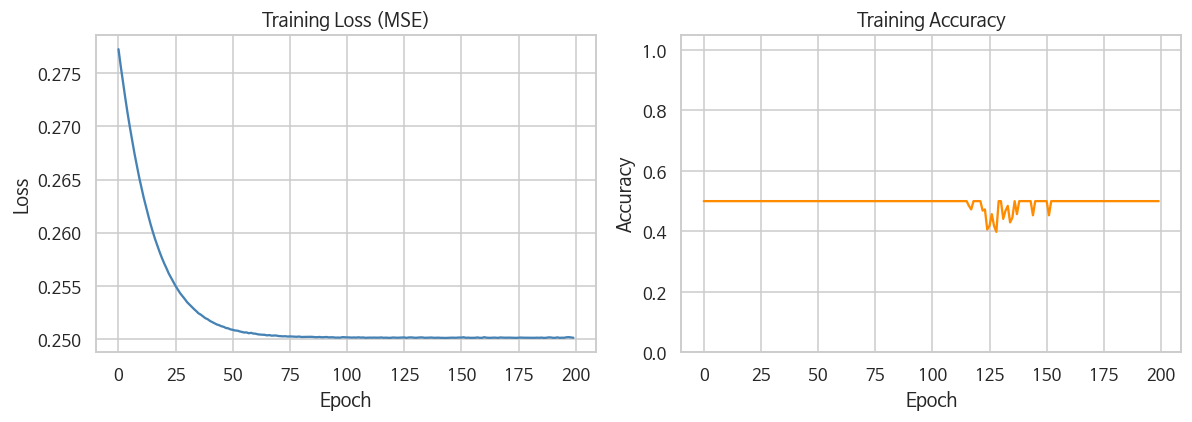

In [12]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['loss'], color='steelblue')
axes[0].set_title('Training Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history.history['accuracy'], color='darkorange')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## (선택) 더 안정적인 학습 설정

강의 기본 예시는 `MSE + SGD + sigmoid`입니다.  
실무/실험에서는 아래처럼 `Adam + binary_crossentropy + ReLU`를 쓰는 경우도 많습니다.

$$
\mathrm{BCE} = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]
$$


In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers # Dense 레이어 사용을 위한 임포트 추가

# =================================================================
# 1. 모델 설계: ReLU 활성화 함수 도입 및 모델 크기 확장
# - ReLU(Rectified Linear Unit)는 음수를 0으로, 양수를 그대로 통과시켜
#   기존 Sigmoid의 단점인 '기대칭 소실(Gradient Vanishing)' 문제를 극복합니다.
# - 은닉층의 노드 수를 16개로 늘려 모델의 표현력을 키웠습니다.
# =================================================================

model_adam = tf.keras.models.Sequential([
    # [입력층 + 첫 번째 은닉층] 입력 크기 2, 노드 16개, ReLU 사용
    layers.Dense(16, input_dim=2, activation='relu'),

    # [두 번째 은닉층] 노드 16개, ReLU 사용
    layers.Dense(16, activation='relu'),

    # [출력층] 이진 분류의 최종 확률값(0~1)을 얻기 위해 마지막엔 Sigmoid 사용
    layers.Dense(1, activation='sigmoid'),
])


# =================================================================
# 2. 컴파일: 현대적인 손실 함수와 옵티마이저 설정
# - loss='binary_crossentropy': 이진 분류에 최적화된 손실 함수로, 틀린 예측에
#   로그 페널티를 강하게 부여해 MSE보다 가중치를 빠르게 학습시킵니다.
# - optimizer='adam': 학습률(Learning Rate)을 데이터에 맞게 스스로 조절하는
#   가장 대중적이고 성능이 뛰어난 최적화 도구입니다.
# =================================================================

model_adam.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)


# =================================================================
# 3. 모델 학습 및 평가
# - SGD 모델은 200 에포크를 학습했으나, Adam은 성능이 뛰어나 100 에포크만으로도 충분합니다.
# =================================================================

# 학습 진행 (verbose=0으로 진행 과정 출력 생략)
hist_adam = model_adam.fit(train_ds, epochs=100, verbose=0)

# 검증용 원본 데이터(X, y)로 최종 손실과 정확도 평가
loss_a, acc_a = model_adam.evaluate(X, y, verbose=0)

# 4개 입력 패턴에 대한 예측 결과 생성
pred_a = model_adam.predict(X, verbose=0)


# =================================================================
# 4. 결과 출력
# =================================================================

print(f'Adam+BCE evaluate: loss={loss_a:.4f}, acc={acc_a:.4f}')

# .ravel()을 사용해 2차원 출력을 1차원 배열로 평탄화하고 소수점 3자리까지 반올림하여 출력
print('예측 확률:', np.round(pred_a.ravel(), 3))

# 예측 확률이 0.5 이상이면 1, 미만이면 0으로 변환하여 최종 이진 라벨 출력
print('예측 라벨:', (pred_a.ravel() >= 0.5).astype(int))

Adam+BCE evaluate: loss=0.0104, acc=1.0000
예측 확률: [0.022 0.993 0.993 0.006]
예측 라벨: [0 1 1 0]


---
# 정리

1. 딥러닝 학습 = **손실 최소화**를 위한 **최적화**
2. 경사하강법: $W \leftarrow W - \alpha \nabla L$
3. 순전파로 예측, 역전파로 기울기 계산
4. TensorFlow 2.x는 Eager Execution이 기본
5. Constant / Sequence / Variable 텐서를 구분해서 사용
6. Keras로 `Sequential → compile → fit → evaluate → predict` 흐름을 익힌다
7. Epoch / Batch / Iteration 관계를 항상 의식한다

$$
1\ \mathrm{Epoch} = \frac{N}{\text{Batch Size}} = \text{Iterations}
$$

## 참고 링크

- TensorFlow 가이드: [https://www.tensorflow.org/guide](https://www.tensorflow.org/guide)
- Keras Sequential: [https://www.tensorflow.org/guide/keras/sequential_model](https://www.tensorflow.org/guide/keras/sequential_model)
- tf.data: [https://www.tensorflow.org/guide/data](https://www.tensorflow.org/guide/data)
- Backpropagation 논문: [https://www.nature.com/articles/323533a0](https://www.nature.com/articles/323533a0)
